# Gradient Diagnostics: Forward-Backward Gain Asymmetry

This notebook investigates **why** row-centered initializations cause gradient instability
despite preserving geometry. The analysis is motivated by the 4 backpropagation equations
and the advisor's observations:

1. **Single data point test**: Does the gradient pattern hold for a single sample? If yes,
   the issue is in σ'(z^l) and the weight structure, not aggregation.

2. **Forward-backward gain decomposition**: Since ∂C/∂W^l = δ^l · (a^{l-1})^T,
   we decompose the gradient into its forward (activation) and backward (error signal)
   components to identify the source of instability.

3. **Centering ratio**: Var(a)/E[a²] measures how much row-centering reduces the
   effective forward gain. For half-Gaussian post-ReLU: ≈ (π-1)/π ≈ 0.68.

4. **Variance sweep**: Confirms that no single variance fixes both forward and backward
   gains (the advisor's coupling observation from BP4).

5. **Alpha sweep**: Explores the geometry-gradient Pareto frontier for partial centering.

In [1]:
# Setup
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt
import torch
import math

from rp_study.config import ExperimentConfig, NetworkConfig, GradientExperimentConfig
from rp_study.experiments.gradient_analysis import (
    GradientExperiment, compare_initializations, ExperimentResults
)
from rp_study.visualization.gradient_plots import (
    plot_gain_decomposition, plot_signal_norms, compare_gains_plot,
    plot_relu_survival, plot_centering_ratio, compare_initializations_plot,
    plot_row_norm_per_layer,
)
from rp_study.models.initializers import list_initializers

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
print(f"Available initializers: {list_initializers()}")

Device: cpu
Available initializers: ['he', 'row_centered_he', 'row_centered_he_var_adj', 'partial_centered_he', 'orthogonal_he', 'orthogonal_tuned', 'centered_with_dc_he', 'custom_variance', 'xavier', 'uniform_he', 'orthogonal', 'kernel_preserving', 'angle_preserving', 'row_centered_final', 'row_centered_layer_balanced', 'row_centered_layer_balanced_he_base', 'row_centered_forward_balanced', 'row_centered_product_balanced', 'row_centered_layer_balanced_product_base']


In [ ]:
# ====== CONFIGURATION ======

SEED = 42
DATASET = "fashion_mnist"       # Options: "mnist", "fashion_mnist", "cifar10"
DATA_DIR = "../data"

# Derive input dimension from dataset
_DATASET_INPUT_DIMS = {"mnist": 784, "fashion_mnist": 784, "cifar10": 3072}
INPUT_DIM = _DATASET_INPUT_DIMS[DATASET]

# Initializers to compare (core three only)
INIT_STRATEGIES = [
    "he",                              # Baseline
    "row_centered_forward_balanced",    # g_fwd = 1, g_bwd = 1.21
    "row_centered_product_balanced",    # g_fwd * g_bwd = 1
]

INIT_LABELS = {
    "he": "He (baseline)",
    "row_centered_forward_balanced": "Row-Centered (fwd balanced)",
    "row_centered_product_balanced": "Row-Centered (product balanced)",
}

# Network architecture
N_HIDDEN = 50
WIDTH = INPUT_DIM
LAYER_SIZES = [INPUT_DIM] + [WIDTH] * N_HIDDEN + [1]

# Sample counts
NUM_SAMPLES_FULL = 2000
NUM_SAMPLES_SINGLE = 1

print(f"Dataset: {DATASET} (input_dim={INPUT_DIM})")
print(f"Architecture: {LAYER_SIZES[0]} -> [{WIDTH}] x {N_HIDDEN} -> {LAYER_SIZES[-1]}")
print(f"Initializers: {INIT_STRATEGIES}")

## Section 1: Single vs Multi-Sample Comparison

**Advisor's suggestion (BP2)**: If the gradient pattern (explosion/vanishing) holds for
a single data point, then the cause is structural — in σ'(z^l) and the weight matrices —
not in the aggregation over many samples.

We compare gradient row norms with `num_samples=1` vs `num_samples=2000`.

In [3]:
# Run with full batch
print(f"Running gradient analysis with {NUM_SAMPLES_FULL} samples...")
results_full = compare_initializations(
    layer_sizes=LAYER_SIZES,
    init_strategies=INIT_STRATEGIES,
    num_samples=NUM_SAMPLES_FULL,
    dataset=DATASET,
    seed=SEED,
)
print("Done!")

Running gradient analysis with 2000 samples...


/Users/itayofer/Thesis/Thesis/notebooks/../src/rp_study/experiments/gradient_analysis.py:290: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss.backward()


Done!


In [5]:
# Run with single data point
print(f"Running gradient analysis with {NUM_SAMPLES_SINGLE} sample...")
results_single = compare_initializations(
    layer_sizes=LAYER_SIZES,
    init_strategies=INIT_STRATEGIES,
    num_samples=NUM_SAMPLES_SINGLE,
    dataset=DATASET,
    seed=SEED,
)
print("Done!")

Running gradient analysis with 1 sample...
Done!


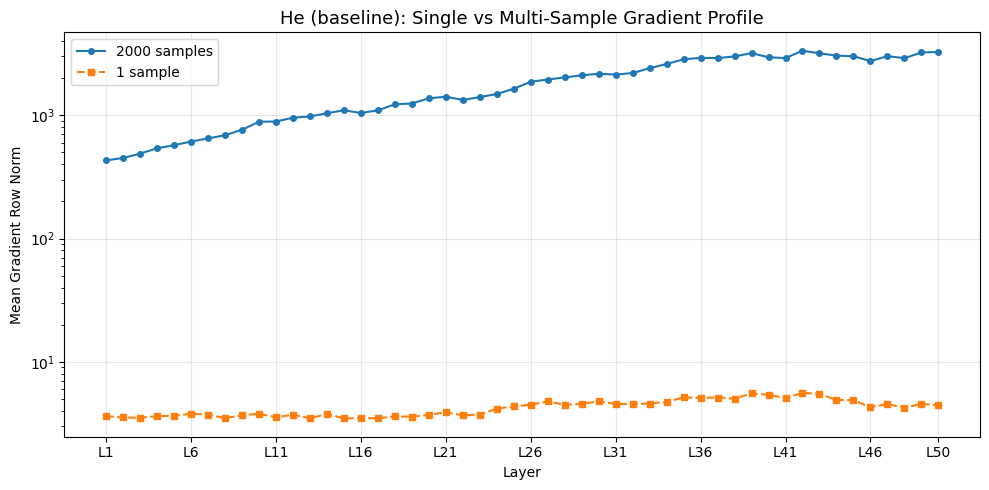

  He (baseline): log-scale correlation = 0.8635 (different pattern)


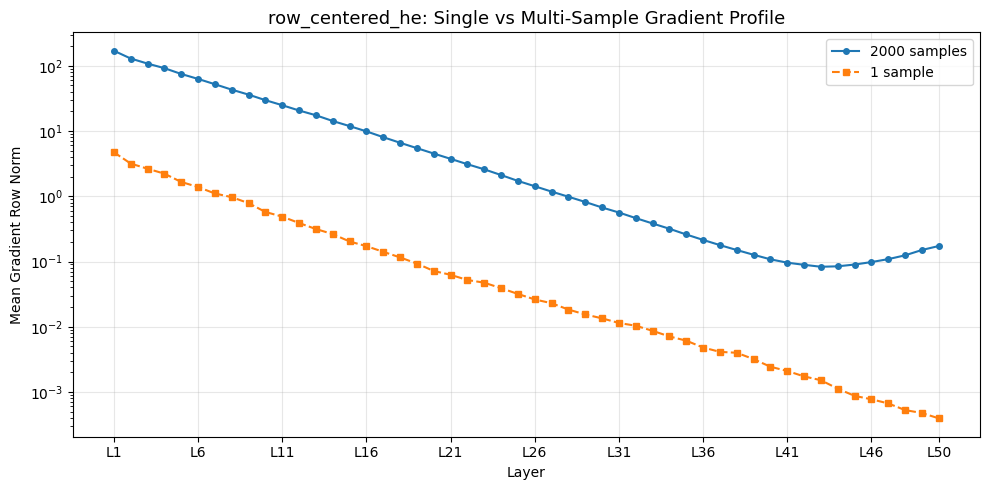

  row_centered_he: log-scale correlation = 0.9846 (same pattern)


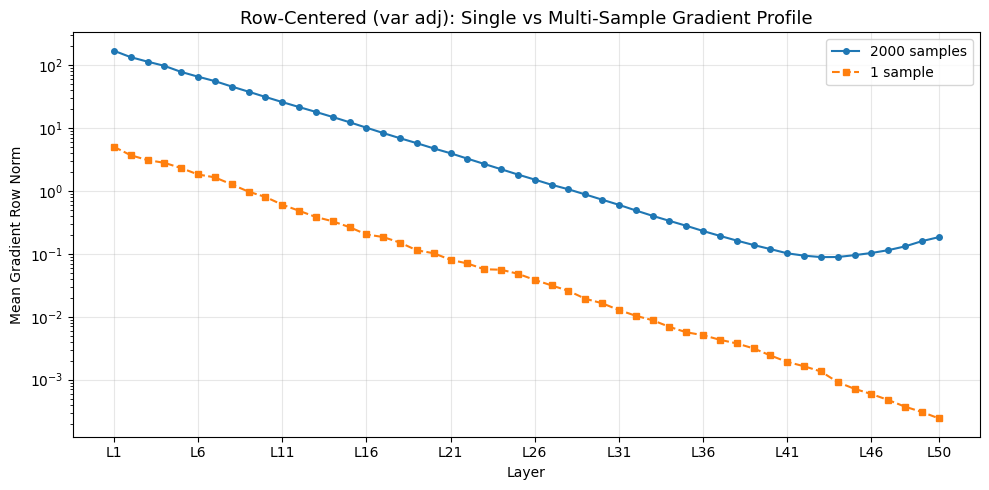

  Row-Centered (var adj): log-scale correlation = 0.9794 (same pattern)


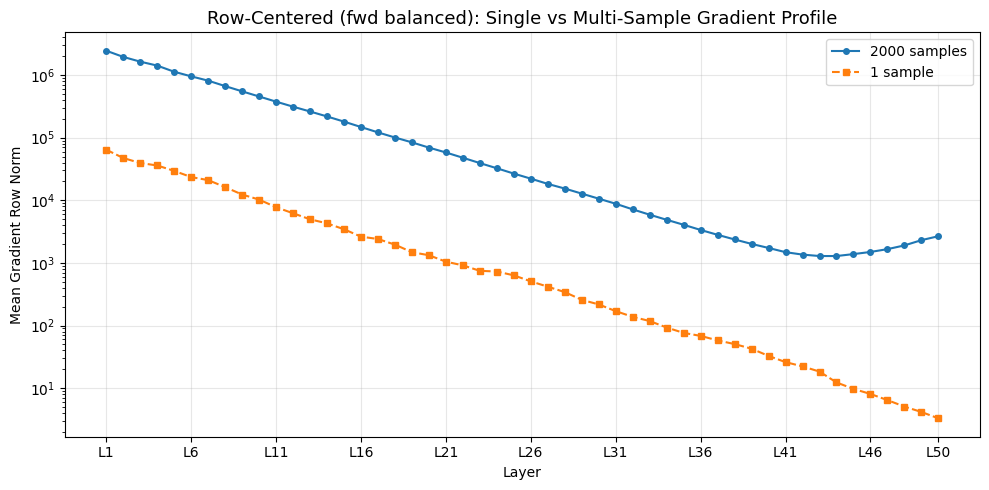

  Row-Centered (fwd balanced): log-scale correlation = 0.9793 (same pattern)


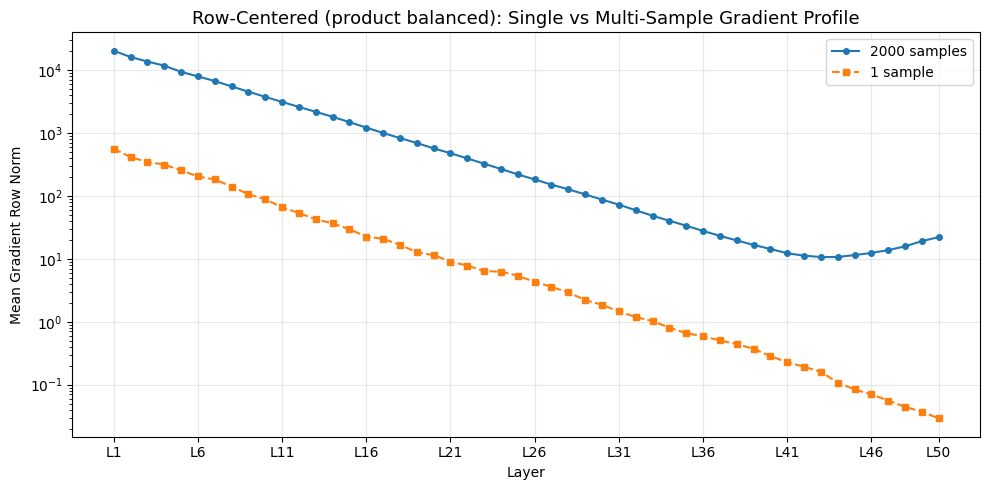

  Row-Centered (product balanced): log-scale correlation = 0.9796 (same pattern)


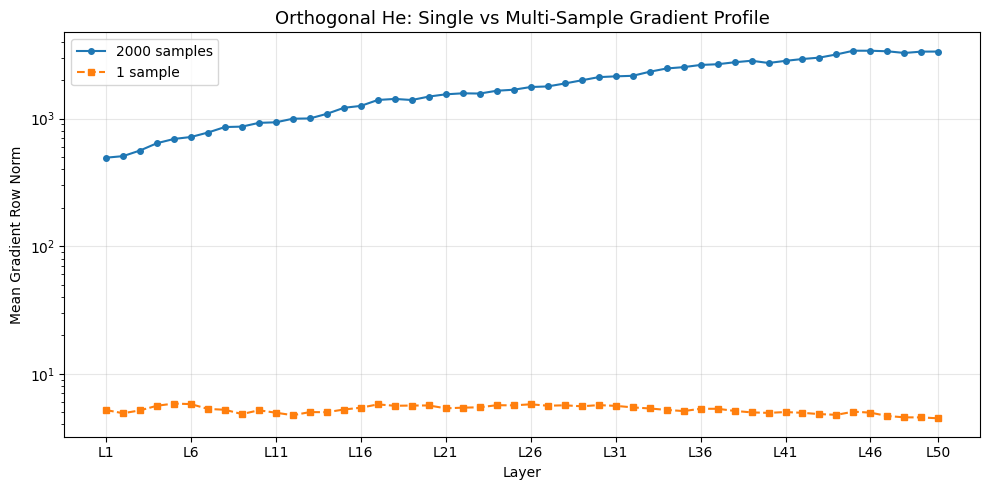

  Orthogonal He: log-scale correlation = -0.3195 (different pattern)


In [6]:
# Compare gradient norm profiles: single vs multi-sample (overlaid)
for init in INIT_STRATEGIES:
    label = INIT_LABELS.get(init, init)
    fig, ax = plt.subplots(figsize=(10, 5))

    # Full batch
    norms_full = results_full[init].get_mean_row_norms()
    layers = list(norms_full.keys())[:-1]  # exclude output layer
    vals_full = [norms_full[k] for k in layers]
    ax.plot(layers, vals_full, 'o-', markersize=4, label=f'{NUM_SAMPLES_FULL} samples')

    # Single sample
    norms_single = results_single[init].get_mean_row_norms()
    vals_single = [norms_single[k] for k in layers]
    ax.plot(layers, vals_single, 's--', markersize=4, label=f'{NUM_SAMPLES_SINGLE} sample')

    ax.set_yscale('log')
    ax.set_xlabel('Layer')
    ax.set_ylabel('Mean Gradient Row Norm')
    ax.set_title(f'{label}: Single vs Multi-Sample Gradient Profile', fontsize=13)
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Thin x-axis for readability
    if len(layers) > 10:
        step = max(1, (len(layers) - 1) // 9)
        visible = list(range(0, len(layers), step))
        if len(layers) - 1 not in visible:
            visible.append(len(layers) - 1)
        ax.set_xticks([layers[i] for i in visible])

    plt.tight_layout()
    plt.show()

    # Print correlation
    if len(vals_full) > 0 and len(vals_single) > 0:
        log_corr = np.corrcoef(np.log(np.array(vals_full) + 1e-20),
                               np.log(np.array(vals_single) + 1e-20))[0, 1]
        print(f'  {label}: log-scale correlation = {log_corr:.4f}'
              f' ({"same pattern" if log_corr > 0.9 else "different pattern"})')

## Section 2: Forward-Backward Gain Decomposition

Since ∂C/∂W^l = δ^l · (a^{l-1})^T (BP4), the gradient norm is proportional to
||δ^l|| · ||a^{l-1}||. By tracking these separately, we can identify:

- **Forward signal**: rms(a^l) — does it grow, shrink, or stay constant with depth?
- **Backward signal**: rms(δ^l) — does the error signal explode or vanish?
- **Centering ratio**: Var(a)/E[a²] — the "smoking gun" for the forward-backward asymmetry

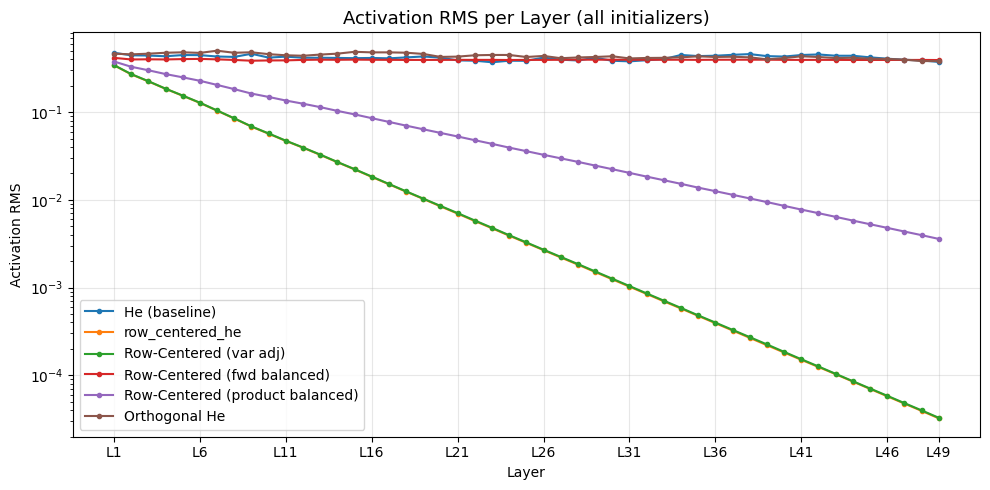

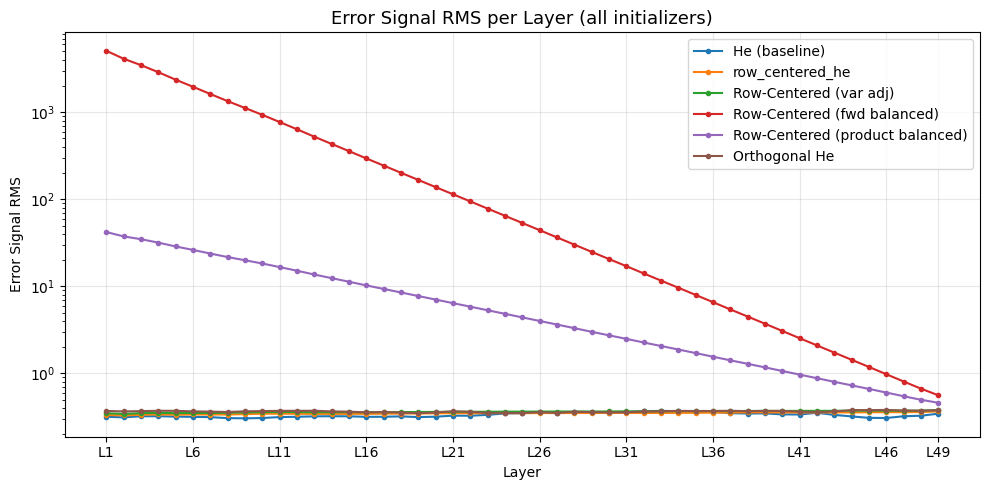

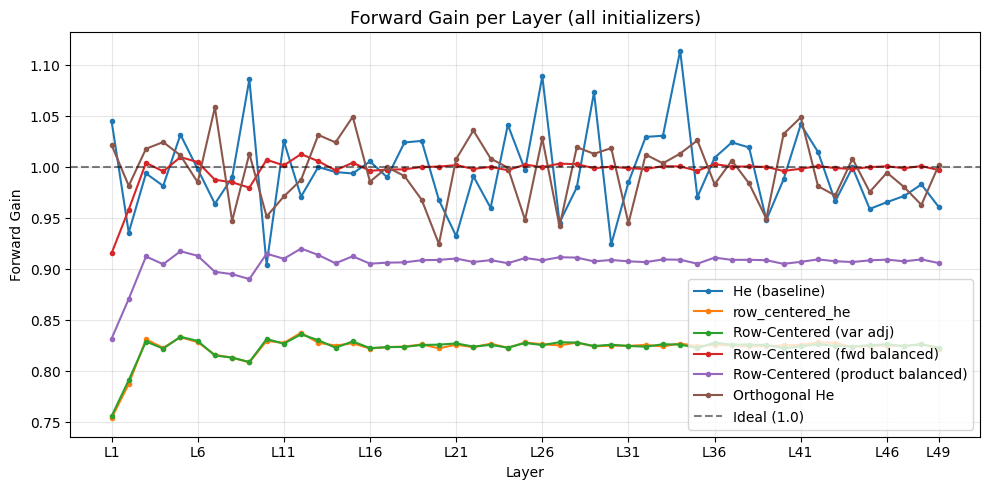

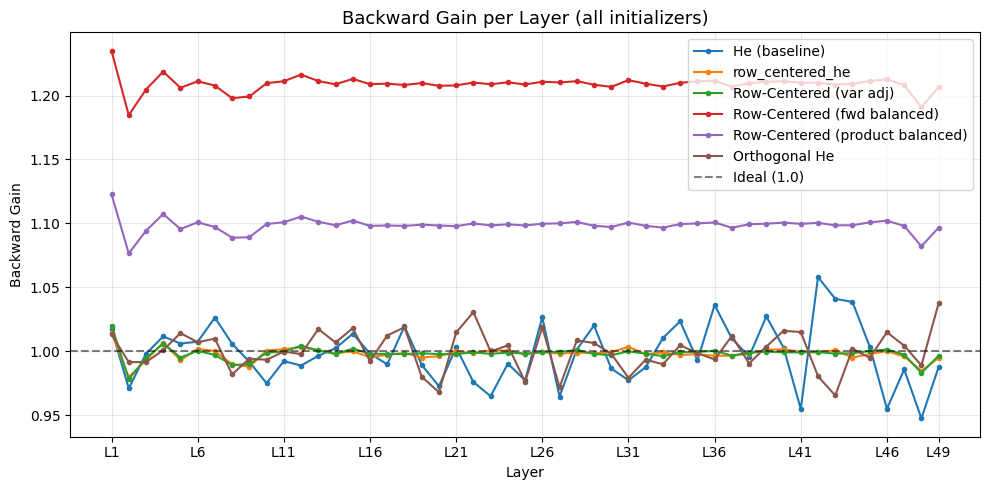

In [7]:
# Signal norm decomposition — all initializers overlaid per metric
from rp_study.experiments.gradient_analysis import LayerSignalStats

FIGDIR = '../reports/latex/figures'

metrics = {
    "Activation RMS": lambda s: s.activation_rms,
    "Error Signal RMS": lambda s: s.error_signal_rms,
}

fignames = {"Activation RMS": "activation_rms", "Error Signal RMS": "error_signal_rms"}

# Activation RMS and Error Signal RMS (from signal_stats)
for metric_name, extractor in metrics.items():
    fig, ax = plt.subplots(figsize=(10, 5))
    for init in INIT_STRATEGIES:
        label = INIT_LABELS.get(init, init)
        stats = results_full[init].signal_stats
        if not stats:
            continue
        stats_trimmed = stats[:-1] if len(stats) > 1 else stats
        layers = [f"L{s.layer_idx}" for s in stats_trimmed]
        vals = [extractor(s) for s in stats_trimmed]
        ax.plot(layers, vals, 'o-', markersize=3, label=label)

    ax.set_yscale('log')
    ax.set_xlabel('Layer')
    ax.set_ylabel(metric_name)
    ax.set_title(f'{metric_name} per Layer (all initializers)', fontsize=13)
    ax.legend()
    ax.grid(True, alpha=0.3)
    if len(layers) > 10:
        step = max(1, (len(layers) - 1) // 9)
        visible = list(range(0, len(layers), step))
        if len(layers) - 1 not in visible:
            visible.append(len(layers) - 1)
        ax.set_xticks([layers[i] for i in visible])
    plt.tight_layout()
    fig.savefig(f'{FIGDIR}/{fignames[metric_name]}.png', dpi=150, bbox_inches='tight')
    plt.show()

# Forward gain and Backward gain (from get_forward_gains / get_backward_gains)
for gain_type, getter in [("Forward Gain", "get_forward_gains"), ("Backward Gain", "get_backward_gains")]:
    fig, ax = plt.subplots(figsize=(10, 5))
    for init in INIT_STRATEGIES:
        label = INIT_LABELS.get(init, init)
        result = results_full[init]
        gains = getattr(result, getter)()
        layers = list(gains.keys())
        # Exclude last hidden layer (boundary effect)
        if len(layers) > 1:
            layers = layers[:-1]
        vals = [gains[k] for k in layers]
        ax.plot(layers, vals, 'o-', markersize=3, label=label)

    ax.axhline(y=1.0, color='black', linestyle='--', alpha=0.5, label='Ideal (1.0)')
    ax.set_xlabel('Layer')
    ax.set_ylabel(gain_type)
    ax.set_title(f'{gain_type} per Layer (all initializers)', fontsize=13)
    ax.legend()
    ax.grid(True, alpha=0.3)
    if len(layers) > 10:
        step = max(1, (len(layers) - 1) // 9)
        visible = list(range(0, len(layers), step))
        if len(layers) - 1 not in visible:
            visible.append(len(layers) - 1)
        ax.set_xticks([layers[i] for i in visible])
    plt.tight_layout()
    fname = "forward_gain" if "Forward" in gain_type else "backward_gain"
    fig.savefig(f'{FIGDIR}/{fname}_per_layer.png', dpi=150, bbox_inches='tight')
    plt.show()

In [ ]:
# Gain PRODUCT per layer: g_fwd * g_bwd
# From BP4: the gradient is proportional to rms(A^{l-1}) * rms(delta^l).
# If the product of gains = 1 at each layer, the gradient-relevant signal
# is preserved per layer. This is the key property of product-balanced init.

fig, ax = plt.subplots(figsize=(10, 5))

for init in INIT_STRATEGIES:
    label = INIT_LABELS.get(init, init)
    result = results_full[init]
    fwd_gains = result.get_forward_gains()
    bwd_gains = result.get_backward_gains()
    
    # Match layers (both dicts have the same keys)
    layers = list(fwd_gains.keys())
    if len(layers) > 1:
        layers = layers[:-1]  # exclude last hidden layer
    
    products = [fwd_gains[k] * bwd_gains[k] for k in layers]
    ax.plot(layers, products, 'o-', markersize=3, label=label)

ax.axhline(y=1.0, color='black', linestyle='--', alpha=0.5, label='Ideal (1.0)')
ax.set_xlabel('Layer')
ax.set_ylabel('Forward Gain × Backward Gain')
ax.set_title('Gain Product (g_fwd × g_bwd) per Layer — all initializers', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)

if len(layers) > 10:
    step = max(1, (len(layers) - 1) // 9)
    visible = list(range(0, len(layers), step))
    if len(layers) - 1 not in visible:
        visible.append(len(layers) - 1)
    ax.set_xticks([layers[i] for i in visible])

plt.tight_layout()
fig.savefig(f'{FIGDIR}/gain_product_per_layer.png', dpi=150, bbox_inches='tight')
plt.show()

# Print median products
print(f'{"Initializer":>40s}  {"Median Product":>14s}')
print('-' * 58)
for init in INIT_STRATEGIES:
    label = INIT_LABELS.get(init, init)
    result = results_full[init]
    fwd = result.get_forward_gains()
    bwd = result.get_backward_gains()
    layers = list(fwd.keys())[:-1]
    products = [fwd[k] * bwd[k] for k in layers]
    print(f'{label:>40s}  {np.median(products):>14.4f}')


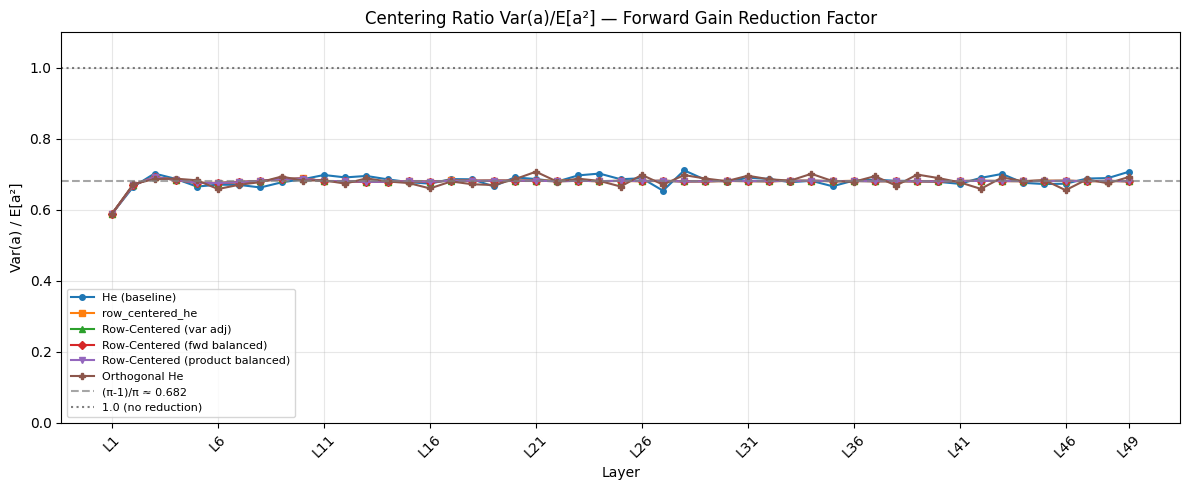

Interpretation:
  - This ratio is a property of the ACTIVATIONS, not the weights
  - For standard He: the ratio does NOT affect forward gain (weights are not row-centered)
  - For row-centered: the forward gain is MULTIPLIED by this ratio
  - Theoretical half-Gaussian value: (π-1)/π ≈ 0.6817


In [8]:
# Create labeled results dict for plotting functions
results_labeled = {INIT_LABELS.get(init, init): results_full[init] for init in INIT_STRATEGIES}

# Centering ratio: the "smoking gun"
fig = plot_centering_ratio(results_labeled)
plt.title('Centering Ratio Var(a)/E[a²] — Forward Gain Reduction Factor', fontsize=12)
fig.savefig(f'{FIGDIR}/centering_ratio.png', dpi=150, bbox_inches='tight')
plt.show()

print('Interpretation:')
print('  - This ratio is a property of the ACTIVATIONS, not the weights')
print('  - For standard He: the ratio does NOT affect forward gain (weights are not row-centered)')
print('  - For row-centered: the forward gain is MULTIPLIED by this ratio')
print('  - Theoretical half-Gaussian value: (π-1)/π ≈', f'{(math.pi-1)/math.pi:.4f}')

## Section 3: ReLU Survival Analysis

Does row-centering change the fraction of neurons that survive ReLU?
Standard He predicts ~50% survival. Centering might change this.

In [ ]:
fig = plot_relu_survival(results_labeled)
plt.title('ReLU Survival Rate per Layer', fontsize=12)
plt.show()

# Summary statistics
for init in INIT_STRATEGIES:
    label = INIT_LABELS.get(init, init)
    rates = results_full[init].get_relu_survival_rates()
    vals = list(rates.values())
    print(f'{label}: survival = {np.mean(vals):.3f} ± {np.std(vals):.3f}')

## Section 4: Variance Sweep (Advisor's Coupling Observation)

From BP4: ∂C/∂W^l ∝ W¹ · ... · W^{l-1} · (W^{l+1})^T · ... · (W^L)^T

The advisor observed: changing variance at one layer affects gradients at other
layers differently depending on whether they're "forward" or "backward" from the
modified layer. We sweep variance factors to visualize this coupling.

For row-centered initialization, we expect:
- **Forward gain** scales linearly with variance (more variance → more signal)
- **Backward gain** ALSO scales with variance, but the RATIO forward/backward
  stays constant at Var(a)/E[a²] ≈ 0.68

This means no single variance can make both gains = 1 simultaneously.

In [ ]:
# Variance sweep for row-centered initialization
# We use custom_variance + manual row-centering via a helper
import torch.nn as nn
from rp_study.models.initializers import register_initializer, initialize_layer

VARIANCE_FACTORS = [1.5, 2.0, 2.5, 3.0]

variance_results = {}
for factor in VARIANCE_FACTORS:
    label = f'RC var={factor:.1f}/d'

    # Register a temporary initializer for this factor
    init_name = f'_sweep_rc_{factor}'

    @register_initializer(init_name)
    def _sweep_init(layer, _factor=factor, **kwargs):
        fan_in = layer.weight.shape[1]
        target_std = math.sqrt(_factor / fan_in)
        with torch.no_grad():
            layer.weight.normal_(0.0, target_std)
            layer.weight -= layer.weight.mean(dim=1, keepdim=True)
            row_stds = layer.weight.std(dim=1, keepdim=True, unbiased=False)
            row_stds = torch.clamp(row_stds, min=1e-8)
            layer.weight *= target_std / row_stds
            if layer.bias is not None:
                layer.bias.zero_()

    exp_config = ExperimentConfig(seed=SEED, data_dir=DATA_DIR)
    exp_config.setup_seeds()
    grad_config = GradientExperimentConfig(num_samples=NUM_SAMPLES_FULL, dataset=DATASET)
    net_config = NetworkConfig(layer_sizes=LAYER_SIZES, init_strategy=init_name)
    exp = GradientExperiment(exp_config, net_config, grad_config)
    variance_results[label] = exp.run()
    print(f'  {label}: done')

print('Variance sweep complete!')

In [ ]:
# Plot forward and backward gains for the variance sweep
fig = compare_gains_plot(variance_results, gain_type='forward')
plt.title('Forward Gain vs Variance Factor (row-centered)', fontsize=12)
plt.show()

fig = compare_gains_plot(variance_results, gain_type='backward')
plt.title('Backward Gain vs Variance Factor (row-centered)', fontsize=12)
plt.show()

# Summary: median forward and backward gains for each factor
print(f'{"Factor":>10s}  {"Median Fwd":>10s}  {"Median Bwd":>10s}  {"Ratio F/B":>10s}')
print('-' * 45)
for label, result in variance_results.items():
    fwd = list(result.get_forward_gains().values())
    bwd = list(result.get_backward_gains().values())
    # Exclude last hidden layer (boundary effect)
    fwd = fwd[:-1] if len(fwd) > 1 else fwd
    bwd = bwd[:-1] if len(bwd) > 1 else bwd
    med_fwd = np.median(fwd)
    med_bwd = np.median(bwd)
    ratio = med_fwd / med_bwd if med_bwd > 0 else float('nan')
    print(f'{label:>10s}  {med_fwd:>10.4f}  {med_bwd:>10.4f}  {ratio:>10.4f}')

print(f'\nTheoretical ratio (π-1)/π = {(math.pi-1)/math.pi:.4f}')
print('Note: The ratio is approximately constant — confirming that no single')
print('variance can simultaneously fix both forward and backward gains.')

## Section 5: Alpha Sweep for Partial Centering

Since the asymmetry is structural (caused by row-centering + ReLU), the only way to
reduce it is to use **partial centering**: `W = W_he - α · mean(W_he, dim=1)`.

- α = 0: standard He (perfect gradients, bad geometry)
- α = 1: full centering (perfect geometry, bad gradients)

We sweep α to find the Pareto-optimal trade-off.

In [ ]:
from sklearn.decomposition import PCA
from rp_study.data.loaders import get_data_loader
from rp_study.projections import multi_layer_rp_with_init

ALPHA_VALUES = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
GEOM_N_LAYERS = 20  # layers for geometry test

# Load data for geometry test
config = ExperimentConfig(seed=SEED, data_dir=DATA_DIR)
config.setup_seeds()
X_geom, y_geom = get_data_loader(
    dataset_name=DATASET, data_dir=DATA_DIR, train=True,
    flatten=True, as_numpy=True
)

alpha_results = {}   # gradient results
alpha_geometry = {}  # PCA projections for geometry

for alpha in ALPHA_VALUES:
    label = f'α={alpha:.1f}'
    init_name = f'_sweep_alpha_{alpha}'

    @register_initializer(init_name)
    def _alpha_init(layer, _alpha=alpha, **kwargs):
        fan_in = layer.weight.shape[1]
        target_std = math.sqrt(2.0 / fan_in)
        with torch.no_grad():
            layer.weight.normal_(0.0, target_std)
            layer.weight -= _alpha * layer.weight.mean(dim=1, keepdim=True)
            # Rescale to restore He variance
            row_stds = layer.weight.std(dim=1, keepdim=True, unbiased=False)
            row_stds = torch.clamp(row_stds, min=1e-8)
            layer.weight *= target_std / row_stds
            if layer.bias is not None:
                layer.bias.zero_()

    # Gradient analysis
    exp_config = ExperimentConfig(seed=SEED, data_dir=DATA_DIR)
    exp_config.setup_seeds()
    grad_config = GradientExperimentConfig(num_samples=NUM_SAMPLES_FULL, dataset=DATASET)
    net_config = NetworkConfig(layer_sizes=LAYER_SIZES, init_strategy=init_name)
    exp = GradientExperiment(exp_config, net_config, grad_config)
    alpha_results[label] = exp.run()

    # Geometry analysis (multi-layer RP + PCA)
    X_proj = multi_layer_rp_with_init(
        X_geom, GEOM_N_LAYERS, init_strategy=init_name,
        seed=SEED, device=DEVICE,
    )
    pca = PCA(n_components=2)
    alpha_geometry[label] = pca.fit_transform(X_proj)

    print(f'  {label}: done')

print('Alpha sweep complete!')

In [ ]:
# Geometry: PCA projections for each alpha
n_alphas = len(ALPHA_VALUES)
fig, axes = plt.subplots(1, n_alphas, figsize=(4 * n_alphas, 3.5))
if n_alphas == 1:
    axes = [axes]

for i, alpha in enumerate(ALPHA_VALUES):
    label = f'α={alpha:.1f}'
    X_vis = alpha_geometry[label]
    axes[i].scatter(X_vis[:, 0], X_vis[:, 1], s=2, c=y_geom, cmap='viridis', alpha=0.7)
    axes[i].set_title(label, fontsize=12)
    axes[i].set_xticks([])
    axes[i].set_yticks([])
    axes[i].axis('equal')

plt.suptitle(f'Geometry after {GEOM_N_LAYERS} Layers: Partial Centering Alpha Sweep',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Forward and backward gains for each alpha
fig = compare_gains_plot(alpha_results, gain_type='forward')
plt.title('Forward Gain vs Alpha', fontsize=12)
plt.show()

fig = compare_gains_plot(alpha_results, gain_type='backward')
plt.title('Backward Gain vs Alpha', fontsize=12)
plt.show()

In [ ]:
# Gradient norm profiles for each alpha
fig = compare_initializations_plot(
    alpha_results, metric='mean_row_norm',
    exclude_output_layer=True, use_log_scale=True
)
plt.title('Gradient Row Norms: Alpha Sweep (log scale)', fontsize=12)
fig.savefig(f'{FIGDIR}/gradient_norms_alpha_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Pareto frontier: gradient uniformity vs geometry quality
print(f'{"Alpha":>6s}  {"Med Fwd":>8s}  {"Med Bwd":>8s}  {"Grad Spread":>12s}  {"Geometry":>10s}')
print('-' * 55)

for alpha in ALPHA_VALUES:
    label = f'α={alpha:.1f}'
    result = alpha_results[label]

    # Gains (exclude last hidden layer)
    fwd = list(result.get_forward_gains().values())[:-1]
    bwd = list(result.get_backward_gains().values())[:-1]
    med_fwd = np.median(fwd)
    med_bwd = np.median(bwd)

    # Gradient spread: ratio of max to min row norm (hidden layers)
    norms = list(result.get_mean_row_norms().values())
    norms = norms[:-1]  # exclude output
    if min(norms) > 0:
        spread = max(norms) / min(norms)
    else:
        spread = float('inf')

    # Geometry: check if PCA projection has meaningful structure
    X_vis = alpha_geometry[label]
    # Simple metric: variance explained by first PC relative to total
    geom_quality = np.var(X_vis[:, 0]) / (np.var(X_vis[:, 0]) + np.var(X_vis[:, 1]) + 1e-10)

    print(f'{alpha:>6.1f}  {med_fwd:>8.4f}  {med_bwd:>8.4f}  {spread:>12.1f}x  {geom_quality:>10.3f}')

print()
print('Goal: Find alpha with low gradient spread AND good geometry.')
print('Gradient spread close to 1x = uniform gradients across layers.')

## Section 6: Layer-Balanced Row Centering

The alpha sweep (Section 5) showed that partial centering trades geometry for gradients,
but no single alpha gives both. The **layer-balanced** approach takes a different path:

**Keep full row centering** (α=1) at every layer for maximum geometry preservation,
but use knowledge of the network depth L to scale per-layer variance:

$$s_l = r^{\eta \cdot (l - (L+1)/2)}, \quad r = \sqrt{\frac{\pi-1}{\pi}} \approx 0.826$$

This comes from BP4: $\|\nabla_{W^l} C\| \propto \|a^{l-1}\| \cdot \|\delta^l\|$.
With row centering, the forward gain is structurally $r \approx 0.826$ per layer.
The layer-balanced scaling compensates this by boosting early layers (which face
more forward decay) and reducing late layers (which face backward accumulation).

**Parameter η** controls the correction strength:
- η=0: standard row-centered var-adj (gradient ratio ~21× at 20L)
- η=0.5: recommended balance (gradient ratio ~5× at 20L)
- η=1.0: full correction (gradient ratio ~5.7× but activation instability)

In [ ]:
# Layer-balanced gradient analysis: sweep eta values
# Use 20 hidden layers (geometry-relevant depth)
LB_N_HIDDEN = 20
LB_WIDTH = 256
LB_LAYER_SIZES = [INPUT_DIM] + [LB_WIDTH] * LB_N_HIDDEN + [1]

ETA_VALUES = [0.0, 0.25, 0.5, 0.75, 1.0]

# Which layer-balanced base to use for the sweep
LB_INIT_STRATEGY = "row_centered_layer_balanced"  # or "row_centered_layer_balanced_product_base"

lb_results = {}

# Baselines
for strat, label in [("he", "He (baseline)")]:
    exp_config = ExperimentConfig(seed=SEED, data_dir=DATA_DIR)
    exp_config.setup_seeds()
    grad_config = GradientExperimentConfig(num_samples=NUM_SAMPLES_FULL, dataset=DATASET)
    net_config = NetworkConfig(layer_sizes=LB_LAYER_SIZES, init_strategy=strat)
    exp = GradientExperiment(exp_config, net_config, grad_config)
    lb_results[label] = exp.run()
    print(f"  {label}: done")

# Layer-balanced with different eta
for eta in ETA_VALUES:
    label = f"RC Layer-Bal η={eta:.2f}"
    exp_config = ExperimentConfig(seed=SEED, data_dir=DATA_DIR)
    exp_config.setup_seeds()
    grad_config = GradientExperimentConfig(num_samples=NUM_SAMPLES_FULL, dataset=DATASET)
    net_config = NetworkConfig(
        layer_sizes=LB_LAYER_SIZES,
        init_strategy=LB_INIT_STRATEGY,
        init_kwargs={"eta": eta},
    )
    exp = GradientExperiment(exp_config, net_config, grad_config)
    lb_results[label] = exp.run()
    print(f"  {label}: done")

print("Layer-balanced sweep complete!")

In [ ]:
# Gradient norm profiles: He vs layer-balanced at different eta
fig = compare_initializations_plot(
    lb_results, metric='mean_row_norm',
    exclude_output_layer=True, use_log_scale=True
)
plt.title(f'Gradient Row Norms: Layer-Balanced η Sweep ({LB_N_HIDDEN} layers, width={LB_WIDTH})', fontsize=12)
fig.savefig(f'{FIGDIR}/gradient_norms_eta_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

# Forward and backward gain comparison
fig = compare_gains_plot(lb_results, gain_type='forward')
plt.title('Forward Gain: Layer-Balanced η Sweep', fontsize=12)
fig.savefig(f'{FIGDIR}/forward_gain_eta_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

fig = compare_gains_plot(lb_results, gain_type='backward')
plt.title('Backward Gain: Layer-Balanced η Sweep', fontsize=12)
fig.savefig(f'{FIGDIR}/backward_gain_eta_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Summary table: gradient uniformity for each eta
print(f"{'Config':<25} {'Grad Ratio':>10} {'Grad CV':>8} {'Med Fwd':>8} {'Med Bwd':>8}")
print('-' * 65)

for label, result in lb_results.items():
    norms = list(result.get_mean_row_norms().values())
    norms_hidden = norms[:-1]  # exclude output layer
    ratio = max(norms_hidden) / max(min(norms_hidden), 1e-15)
    cv = np.std(norms_hidden) / np.mean(norms_hidden)

    fwd = list(result.get_forward_gains().values())
    bwd = list(result.get_backward_gains().values())
    fwd = fwd[:-1] if len(fwd) > 1 else fwd
    bwd = bwd[:-1] if len(bwd) > 1 else bwd

    print(f"{label:<25} {ratio:>10.2f}x {cv:>8.3f} {np.median(fwd):>8.4f} {np.median(bwd):>8.4f}")

print()
print("η=0.00 is equivalent to row_centered_he_var_adj (gradient ratio ~21×)")
print("η=0.50 is the recommended balance (gradient ratio ~5×)")
print("He baseline shows the target gradient uniformity to aim for")

## Summary

Key findings from this diagnostic notebook:

1. **Single data point**: The gradient pattern (explosion/vanishing) holds for a single sample,
   confirming the cause is structural (σ'(z^l) and weight matrices), not aggregation.
2. **Forward-backward asymmetry**: Row-centering makes forward gain < backward gain
   because the weights operate on centered activations (removing mean E[a] > 0).
3. **Centering ratio**: Var(a)/E[a²] ≈ 0.68 for post-ReLU, confirming the theoretical
   prediction of (π-1)/π.
4. **Variance coupling**: The forward/backward gain ratio is constant ≈ 0.68 regardless
   of variance — confirming no scalar fix exists.
5. **Partial centering**: Alpha sweep reveals the Pareto frontier between geometry
   preservation and gradient stability.
6. **Layer-balanced initialization**: Using knowledge of network depth L to scale per-layer
   variance achieves gradient uniformity (CV ~0.5 at η=0.5) while preserving full row
   centering for geometry. This is a fundamentally different approach from partial centering:
   instead of weakening the geometry constraint, it compensates the gradient asymmetry
   directly via per-layer scaling derived from BP4.